In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import pickle
from pathlib import Path

In [2]:
BASE_DIR = Path().resolve().parent.parent.parent

In [3]:
DATASETS_DIR = BASE_DIR / 'datasets'

In [13]:
games_raw = pd.read_csv(DATASETS_DIR / 'processed' / 'mergedDF.csv', index_col=0)
games = pd.read_pickle(BASE_DIR / 'src' / 'artifacts' / 'games.pkl')
steam_db_relevant_games = pd.read_csv(DATASETS_DIR / 'scraped' / 'steamdb_relevant_games.csv', index_col=0)
steam_failed = pd.read_csv(DATASETS_DIR / 'scraped' / 'steam_failed.csv', index_col=0)
database_results = pd.read_csv(DATASETS_DIR / 'results' / 'results.csv', index_col=0)

---

In [5]:
steam_db_relevant_games.head()

,appid,name
0,3065800,Marathon
1,2483190,Forza Horizon 6
2,1962700,Subnautica 2
3,1808500,ARC Raiders
4,2807960,Battlefield™ 6


In [6]:
steam_db_relevant_games['failed'] = steam_db_relevant_games['appid'].apply(lambda x: True if x in steam_failed.index else False)

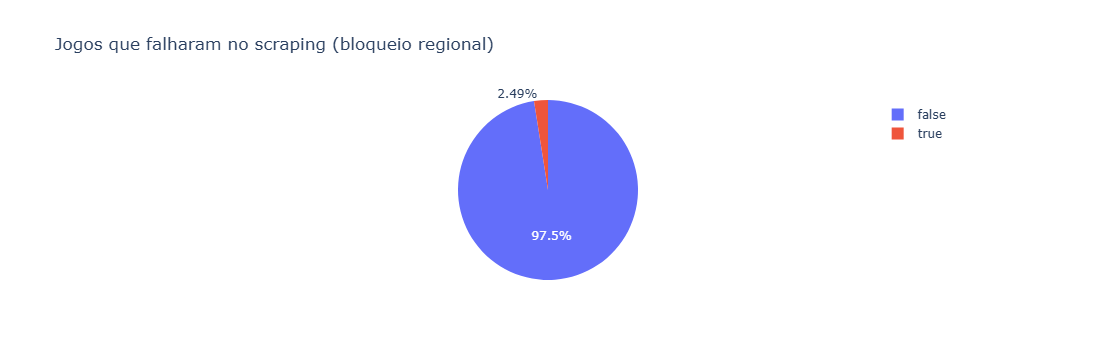

In [7]:
px.pie(steam_db_relevant_games, names='failed', title='Jogos que falharam no scraping (bloqueio regional)')

---

In [8]:
games_raw['failed'] = games_raw['appid'].apply(lambda x: True if x in games['appid'] else False)

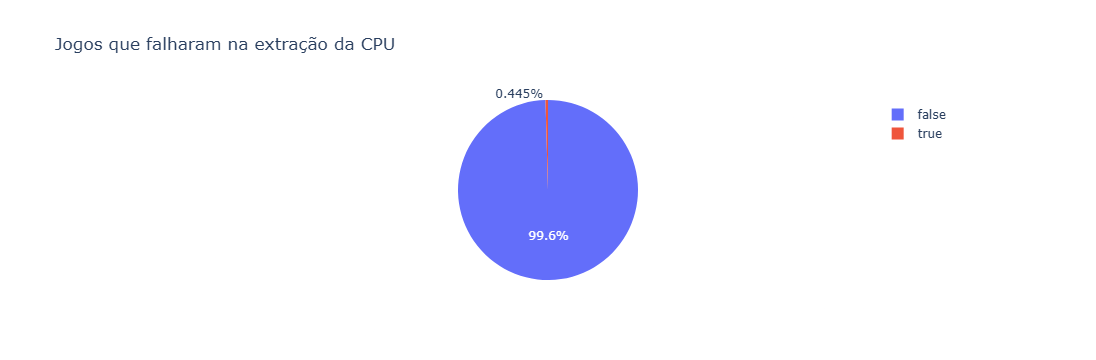

In [9]:
px.pie(games_raw, names='failed', title='Jogos que falharam na extração da CPU')

---

In [11]:
games['isMatchGeneric'] = games['cpu_bench_confidence'].apply(lambda x: True if x < 90 else False)

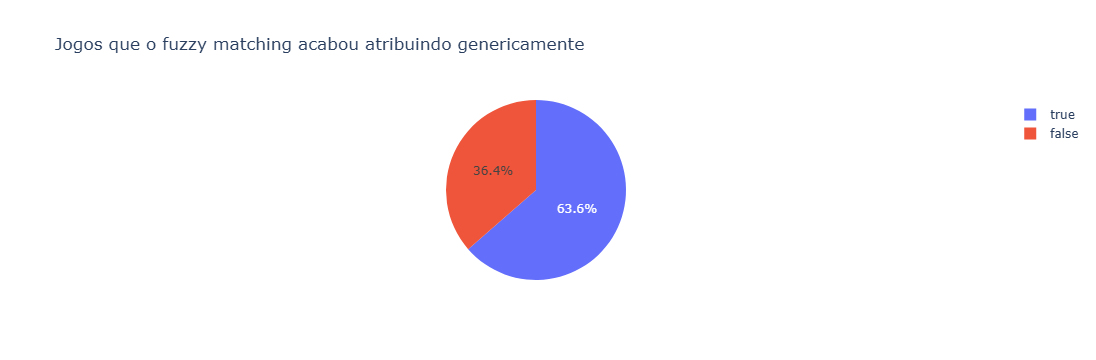

In [12]:
px.pie(games, names='isMatchGeneric', title='Jogos que o fuzzy matching acabou atribuindo genericamente')

---

In [15]:
database_results.head()

,cpu_score,cluster,neighbor_1,neighbor_2,neighbor_3,rating,observations,game_input,game
id,,,,,,,,,
2,92.2,Gamer,Town to City,Mazey Village,LEGO Batman Legacy of the Dark Knight,9,NaN,LEGO Batman Legacy of the Dark Knight,NaN
7,74.0,Gamer,Photography Simulator,Dead Space,Starfield,8,NaN,Crimson Desert,NaN
8,61.5,Pesado,Far Cry 4,Batman Arkham Knight,Middleearth Shadow of Mordor,8,NaN,Forza horizon,NaN
9,55.4,Pesado,Elk Adventure Pack,BossConstructor,Big Buck Hunter Arcade,2,NaN,Fifa,NaN
10,67.6,Pesado,TransRoad USA,Rust,No More Room in Hell 2,8,NaN,Call of dutty,NaN


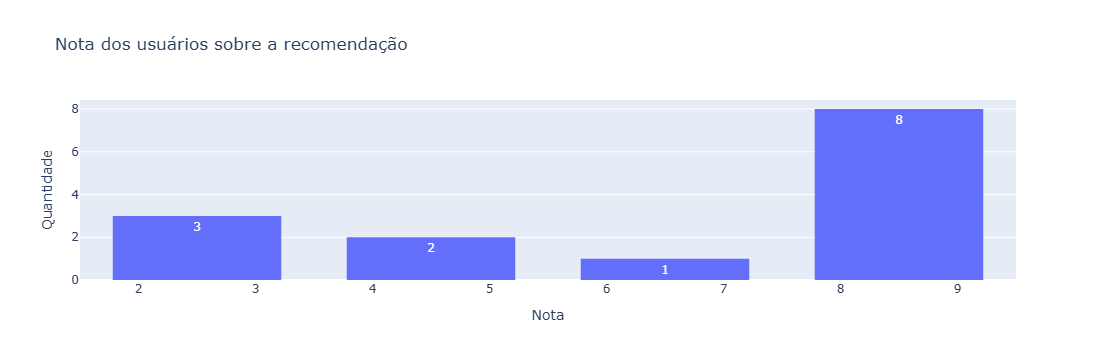

In [22]:
fig = px.histogram(database_results, 'rating', title='Nota dos usuários sobre a recomendação', text_auto=True)
fig.update_layout(
    xaxis_title_text='Nota', # xaxis label
    yaxis_title_text='Quantidade', # yaxis label
    bargap=0.2, # gap between bars of adjacent location coordinates
    bargroupgap=0.1 # gap between bars of the same location coordinates
)

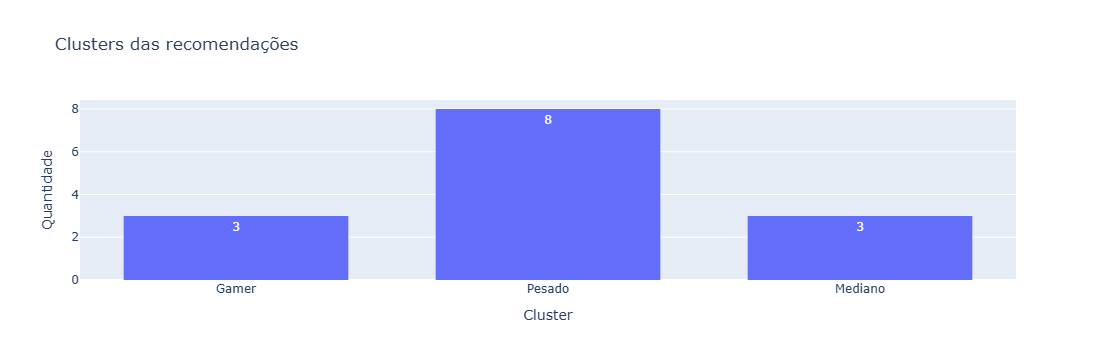

In [25]:
fig = px.histogram(database_results, 'cluster', title='Clusters das recomendações', text_auto=True)
fig.update_layout(
    xaxis_title_text='Cluster', # xaxis label
    yaxis_title_text='Quantidade', # yaxis label
    bargap=0.2, # gap between bars of adjacent location coordinates
    bargroupgap=0.1 # gap between bars of the same location coordinates
)